# Correlations

**Author:** Alexander Michels

This notebook walks through the basics of correlations and spatial correlations in Python.

In [3]:
from esda.moran import (Moran, Moran_BV, Moran_Local, Moran_Local_BV)
import geopandas as gpd
from libpysal.weights.contiguity import Queen
from libpysal import examples
import matplotlib.pyplot as plt
import numpy as np
import random
from scipy.stats import pearsonr, spearmanr
from tqdm import tqdm
from splot.esda import moran_scatterplot, lisa_cluster, plot_moran

## Correlations

First, let's explore calculating straight-forward linear correlations in Python. Let's start with a completely random dataset:

In [4]:
N = 100
x, y = np.random.rand(2, N)
print(x, y)

[0.63797802 0.22279507 0.56860912 0.63063019 0.11856599 0.49792967
 0.86930856 0.33227013 0.9692972  0.90208133 0.80143552 0.60915019
 0.89473432 0.45292213 0.22771662 0.98443977 0.18509533 0.27880397
 0.83001326 0.18106624 0.97139679 0.99617555 0.51176581 0.26849232
 0.85490524 0.13186238 0.87652036 0.77568246 0.36135902 0.5570083
 0.02965599 0.07915081 0.44683859 0.22077532 0.6670175  0.53644497
 0.56521939 0.44047636 0.32219158 0.08296547 0.6623374  0.56465778
 0.69391811 0.5535933  0.77470969 0.61359867 0.19205506 0.35959545
 0.39838517 0.76169238 0.97210216 0.6582882  0.30846974 0.14869892
 0.43706869 0.28161237 0.47775988 0.45453579 0.87978887 0.36004344
 0.40577984 0.58210696 0.35028641 0.3182025  0.74981852 0.70681105
 0.43727669 0.09545553 0.34286495 0.92307562 0.0162215  0.76816083
 0.45558462 0.5325734  0.11105612 0.35998959 0.42556786 0.32622971
 0.54448168 0.46211385 0.78316098 0.73185214 0.74643909 0.4379709
 0.67082835 0.91796025 0.69741933 0.11565967 0.01263199 0.547551

We can plot this dataset using the Pyplot scatterplot:

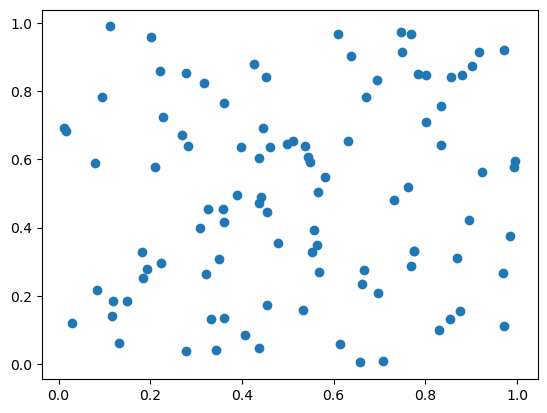

In [5]:
plt.scatter(x, y)

When we calculate the correlation with the scipy `pearsonr` function, we get the correlation coefficient and the p-value for that analysis!

In [6]:
corr_coeff, p_value = pearsonr(x,y)
print(f"The Pearson Correlation is {corr_coeff} with a p-value of {p_value}")

The Pearson Correlation is 0.11749626065475667 with a p-value of 0.2443315699721771


The numpy `polyfit` function allows us to fit a polynomial to this data. We will fit a polynomial with degree one (e.g., a straight line of the form mx+b) and plot both our data and our line of best fit:

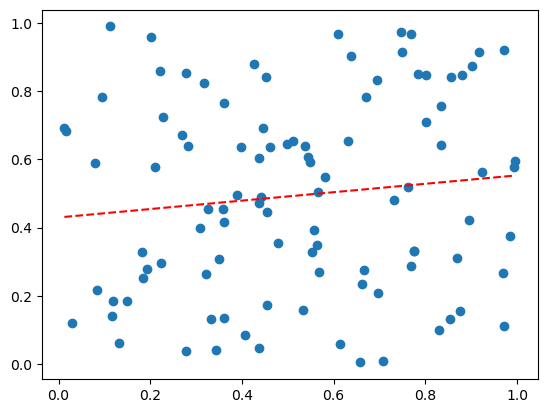

In [7]:
plt.scatter(x, y)
m, b = np.polyfit(x, y, 1)
xlinspace = np.linspace(min(x), max(x), 100)
plt.plot(xlinspace, m * xlinspace + b, 'r--')

From this, we can see that our completely random data (most likely) isn't correlated! Let's see what adding just one outlier to our data can do by adding the data point (10, 10):

In [8]:
x = np.append(x, 10)
y = np.append(y, 10)
print(x, y)

[ 0.63797802  0.22279507  0.56860912  0.63063019  0.11856599  0.49792967
  0.86930856  0.33227013  0.9692972   0.90208133  0.80143552  0.60915019
  0.89473432  0.45292213  0.22771662  0.98443977  0.18509533  0.27880397
  0.83001326  0.18106624  0.97139679  0.99617555  0.51176581  0.26849232
  0.85490524  0.13186238  0.87652036  0.77568246  0.36135902  0.5570083
  0.02965599  0.07915081  0.44683859  0.22077532  0.6670175   0.53644497
  0.56521939  0.44047636  0.32219158  0.08296547  0.6623374   0.56465778
  0.69391811  0.5535933   0.77470969  0.61359867  0.19205506  0.35959545
  0.39838517  0.76169238  0.97210216  0.6582882   0.30846974  0.14869892
  0.43706869  0.28161237  0.47775988  0.45453579  0.87978887  0.36004344
  0.40577984  0.58210696  0.35028641  0.3182025   0.74981852  0.70681105
  0.43727669  0.09545553  0.34286495  0.92307562  0.0162215   0.76816083
  0.45558462  0.5325734   0.11105612  0.35998959  0.42556786  0.32622971
  0.54448168  0.46211385  0.78316098  0.73185214  0.

Now, when we calculate the Pearson correlation coefficient, we find a strong correlation with a very small p-value!

In [9]:
corr_coeff, p_value = spearmanr(x,y)
print(f"The Pearson Correlation is {corr_coeff} with a p-value of {p_value}")

The Pearson Correlation is 0.14304018637157834 with a p-value of 0.1535822150084347


Let's fit a new line to our data and plot it again:

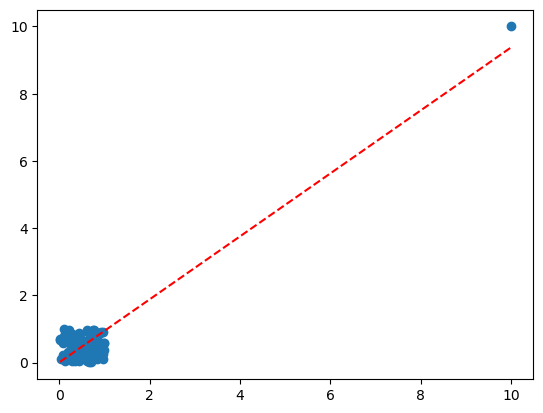

In [10]:
plt.scatter(x, y)
m, b = np.polyfit(x, y, 1)
xlinspace = np.linspace(min(x), max(x), 100)
plt.plot(xlinspace, m * xlinspace + b, 'r--')

This is a reminder that statistics can be easily manipulated, so be careful when working with correlations!

## Spatial Correlations

This section will explore spatial correlations using data from Pysal.

First, let's load our data and visualize it:

In [11]:
guerry = examples.load_example('Guerry')
link_to_data = guerry.get_path('guerry.shp')
gdf = gpd.read_file(link_to_data)
gdf.head()

,dept,Region,Dprtmnt,Crm_prs,Crm_prp,Litercy,Donatns,Infants,Suicids,MainCty,...,Infntcd,Dntn_cl,Lottery,Desertn,Instrct,Prsttts,Distanc,Area,Pop1831,geometry
0,1.0,E,Ain,28870.0,15890.0,37.0,5098.0,33120.0,35039.0,2.0,...,60.0,69.0,41.0,55.0,46.0,13.0,218.372,5762.0,346.03,"POLYGON ((801150.000 2092615.000, 800669.000 2..."
1,2.0,N,Aisne,26226.0,5521.0,51.0,8901.0,14572.0,12831.0,2.0,...,82.0,36.0,38.0,82.0,24.0,327.0,65.945,7369.0,513.00,"POLYGON ((729326.000 2521619.000, 729320.000 2..."
2,3.0,C,Allier,26747.0,7925.0,13.0,10973.0,17044.0,114121.0,2.0,...,42.0,76.0,66.0,16.0,85.0,34.0,161.927,7340.0,298.26,"POLYGON ((710830.000 2137350.000, 711746.000 2..."
3,4.0,E,Basses-Alpes,12935.0,7289.0,46.0,2733.0,23018.0,14238.0,1.0,...,12.0,37.0,80.0,32.0,29.0,2.0,351.399,6925.0,155.90,"POLYGON ((882701.000 1920024.000, 882408.000 1..."
4,5.0,E,Hautes-Alpes,17488.0,8174.0,69.0,6962.0,23076.0,16171.0,1.0,...,23.0,64.0,79.0,35.0,7.0,1.0,320.280,5549.0,129.10,"POLYGON ((886504.000 1922890.000, 885733.000 1..."


<Axes: >

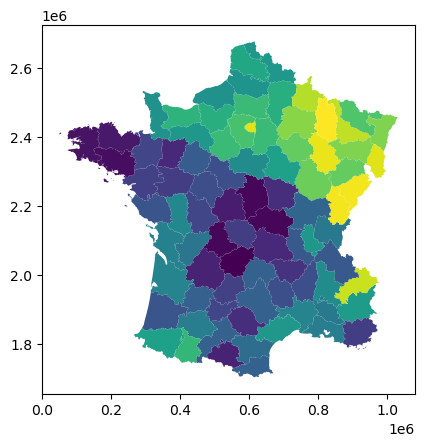

In [12]:
gdf.plot(column='Litercy')

One benefit of having data in a DataFrame (or GeoDataFrame) is that we can quickly calculate a visualize the correlations between our variables:

In [13]:
columns_to_exclude = ["dept", "Region", "Dprtmnt", "geometry"]
corr = gdf[[col for col in gdf.columns if col not in columns_to_exclude]].corr()  # the corr function calculates correlations for us!
corr.style.background_gradient(cmap='coolwarm')

,Crm_prs,Crm_prp,Litercy,Donatns,Infants,Suicids,MainCty,Wealth,Commerc,Clergy,Crm_prn,Infntcd,Dntn_cl,Lottery,Desertn,Instrct,Prsttts,Distanc,Area,Pop1831
Crm_prs,1.000000,0.255208,-0.020631,0.133625,-0.027471,-0.134271,-0.000408,-0.128657,0.096343,0.219201,-0.160987,0.240129,-0.137719,0.048985,0.306047,0.026382,-0.056055,-0.465212,0.285956,0.248384
Crm_prp,0.255208,1.000000,-0.362864,-0.082067,0.278161,0.523349,-0.311157,0.459038,0.441446,-0.091073,0.382305,-0.154800,0.331457,0.464390,-0.282746,0.383108,-0.337132,0.312359,0.118040,-0.280056
Litercy,-0.020631,-0.362864,1.000000,-0.195765,-0.412335,-0.374274,0.082564,-0.274703,-0.602080,-0.163190,-0.217860,0.336058,-0.399321,-0.381734,0.411583,-0.977923,0.298912,-0.318649,-0.247299,0.098249
Donatns,0.133625,-0.082067,-0.195765,1.000000,0.159121,-0.034852,-0.049028,0.118247,0.242561,0.232100,-0.132567,-0.061203,0.180601,0.066950,0.054948,0.221576,-0.063153,-0.134113,0.083600,0.088799
Infants,-0.027471,0.278161,-0.412335,0.159121,1.000000,0.288632,-0.433011,0.341441,0.384213,-0.044668,0.045569,-0.234232,0.084967,0.410769,0.013512,0.442464,-0.278720,0.219028,0.150588,-0.226337
Suicids,-0.134271,0.523349,-0.374274,-0.034852,0.288632,1.000000,-0.200747,0.419455,0.489572,-0.322639,0.353413,-0.084112,0.196464,0.497224,-0.477875,0.363830,-0.214785,0.435394,0.000560,-0.176107
MainCty,-0.000408,-0.311157,0.082564,-0.049028,-0.433011,-0.200747,1.000000,-0.438237,-0.204728,0.190536,-0.138831,0.173001,-0.109544,-0.643927,-0.007860,-0.124600,0.271998,-0.154169,-0.140638,0.548947
Wealth,-0.128657,0.459038,-0.274703,0.118247,0.341441,0.419455,-0.438237,1.000000,0.493834,-0.112939,0.228475,-0.224743,0.346103,0.493133,-0.239740,0.307875,-0.317504,0.428669,0.064796,-0.312517
Commerc,0.096343,0.441446,-0.602080,0.242561,0.384213,0.489572,-0.204728,0.493834,1.000000,-0.088348,0.153071,-0.256082,0.152005,0.432867,-0.345507,0.612415,-0.265706,0.346625,0.153884,-0.030547
Clergy,0.219201,-0.091073,-0.163190,0.232100,-0.044668,-0.322639,0.190536,-0.112939,-0.088348,1.000000,-0.150388,-0.047588,0.341587,-0.256381,0.225764,0.200960,0.198778,-0.264587,0.124259,0.273525


While this is useful, we are interested in the spatial correlation. To calculate this, we will first calculate the Queen contiguity matrix and normalized it:

In [14]:
w = Queen.from_dataframe(gdf)
w.transform = 'r'

Using our weight matrix, we can calculate the Moran's I for any of the variables in our dataset:

In [15]:
x = gdf['Litercy'].values
moran = Moran(x, w)

The `Moran` function will return an object that allows us to inspect the results. For example, the `.I` attribute will tell us the Moran's I and the `.p_sim` attribute will tell us the p-value based on permutation testing:

In [16]:
print(f"The Moran's I is {moran.I} with a p-value of {moran.p_sim}")

The Moran's I is 0.717605262809136 with a p-value of 0.001


We can also visualized the relationship using a scatterplot between the variable and its spatial lag:

(<Figure size 700x700 with 1 Axes>,
 <Axes: title={'center': 'Moran Scatterplot (0.72)'}, xlabel='Attribute', ylabel='Spatial Lag'>)

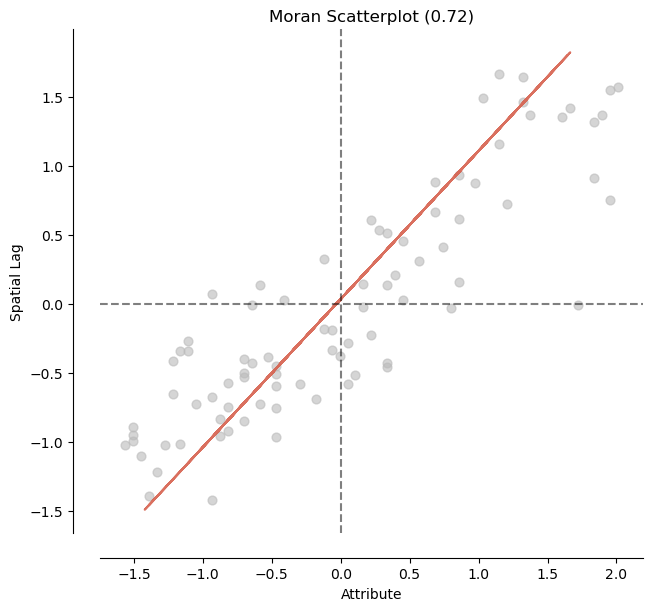

In [15]:
moran_scatterplot(moran)

Next, we will demonstrate how `p_sim` is determined. The following code uses a loop allowing us to perform an experiment repeatedly (`N_SIMS` times to be exact). For each iteration of our loop, we shuffle the values and calculate Moran's I. This allows us to get a distribution of the Moran's I values if the data was random (our null hypothesis).

If you use a small `N_SIMS` value and uncomment the lines `tmp_gdf...` to `plt.close()` you can plot each of the shuffles!

In [16]:
N_SIMS = 1000  # how many simulations to try
var = 'Litercy'

tmp = gdf[var].values  # the data
Is = []  # a list to save the random moran's Is

for i in tqdm(range(N_SIMS)):
    np.random.shuffle(tmp)  # shuffle the values
    moran_tmp = Moran(x, w, permutations=1)  # calculate the Moran's I, only one permutation because we aren't using the p_sim
    # the following lines can be used to plot each shuffle, don't unless you want to make a gif and use a small N_SIMS
    # tmp_gdf = gdf.copy(deep=True)
    # tmp_gdf[var] = tmp
    # ax = tmp_gdf.plot(column=var)
    # ax.figure.savefig(f"Shuffle{i}.png")
    # plt.close()
    Is.append(moran_tmp.I)

  0%|          | 0/1000 [00:00<?, ?it/s]/cvmfs/cybergis.illinois.edu/software/conda/cybergisx/python3-0.9.4/lib/python3.8/site-packages/esda/moran.py:193: RuntimeWarning: divide by zero encountered in double_scalars
  self.z_sim = (self.I - self.EI_sim) / self.seI_sim
100%|██████████| 1000/1000 [00:01<00:00, 730.41it/s]


The following lines are only useful if you plotted the shuffles and can compile the shuffles into a gif!

In [17]:
# import os
# import imageio

# images = []
# for i in range(N_SIMS):
#     fname = f"Shuffle{i}.png"
#     images.append(imageio.imread(fname))

# imageio.mimsave('movie.gif', images, loop=0)

Using these simulations, we can plot the distribution of Moran's I (blue) and the value we actually observe (red).

We have to use proper statistics to get an exact p-value, but we can see from the plot below that it is very unlikely that our actual Moran's I would be observed if the data was random. This leads us to believe that the data is indeed spatially autocorrelated.

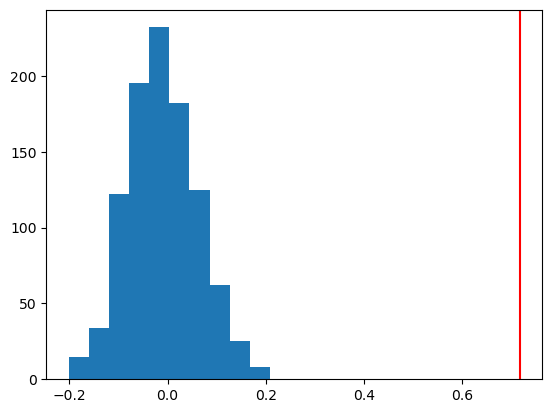

In [18]:
plt.hist(Is)
plt.axvline(x = moran.I, color='red', label="actual Moran's I")
plt.show()

You can also use `plot_moran` to do all of these visualizations. https://pysal.org/notebooks/viz/splot/esda_morans_viz.html

The Moran function actually does all of this in the background for us, we can use the `plot_moran` function to create these plots using the Moran result:

/cvmfs/cybergis.illinois.edu/software/conda/cybergisx/python3-0.9.4/lib/python3.8/site-packages/splot/_viz_esda_mpl.py:354: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sbn.kdeplot(moran.sim, shade=shade, color=color, ax=ax, **kwargs)


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: title={'center': 'Reference Distribution'}, xlabel='Moran I: 0.72', ylabel='Density'>,
        <Axes: title={'center': 'Moran Scatterplot (0.72)'}, xlabel='Attribute', ylabel='Spatial Lag'>],
       dtype=object))

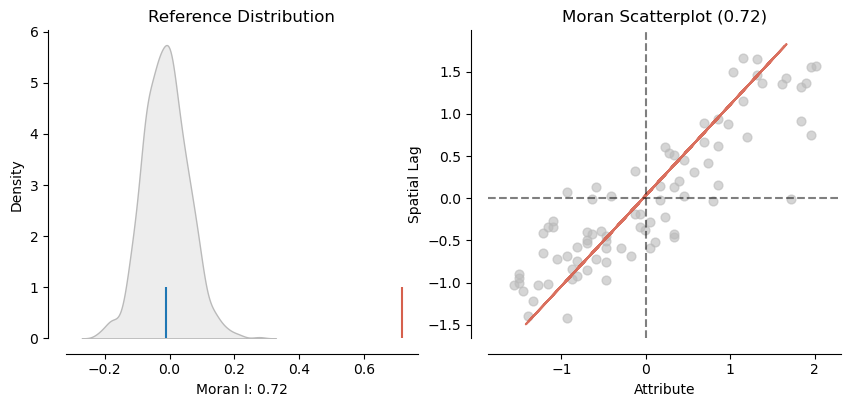

In [19]:
plot_moran(moran)

Lastly, we will example Local Moran's I, using the Wealth variable! We call the function with the variable of interest and the weight matrix:

In [20]:
moran_loc = Moran_Local(gdf['Wealth'].values, w)

Then, we can visualize the different kinds of clusters using the `lisa_cluster` function:

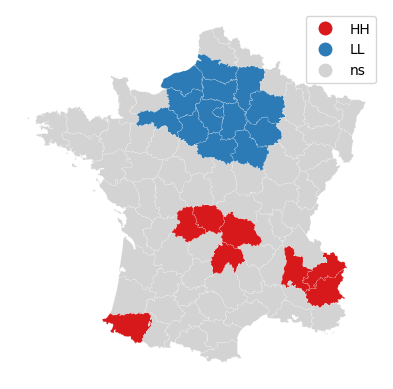

In [21]:
fig = lisa_cluster(moran_loc, gdf)
plt.show()